In [7]:
import pandas as pd
import numpy as np

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
# or CountVectorizer for Bag of Words

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
import pandas as pd

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [10]:
df.info()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


np.int64(0)

In [11]:
df.dropna(inplace=True)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"[^\w\s]", "", text)

    text = re.sub(r"\d+", "", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [16]:
df.columns

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')

In [17]:
df = df.dropna(subset=["Review Text"])

In [18]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["Review Text"] = df["Review Text"].apply(clean_text)

In [19]:
X = df["Review Text"]

y = df["Recommended IND"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [23]:
pred = model.predict(X_test_tfidf)

In [24]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_test, pred))

print("F1 Score:", f1_score(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 0.8812611238240529
F1 Score: 0.9299955029231
              precision    recall  f1-score   support

           0       0.76      0.51      0.61       715
           1       0.90      0.96      0.93      3218

    accuracy                           0.88      3933
   macro avg       0.83      0.74      0.77      3933
weighted avg       0.87      0.88      0.87      3933



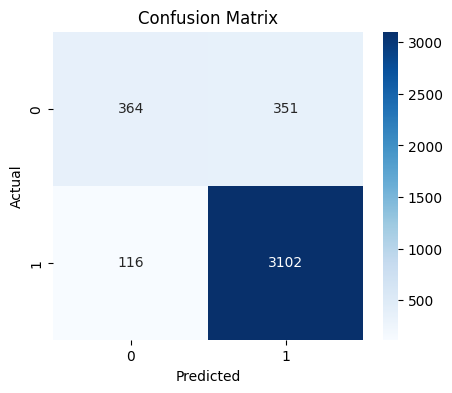

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [26]:
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())

coef = model.coef_[0]

top_positive = feature_names[np.argsort(coef)[-10:]]

top_negative = feature_names[np.argsort(coef)[:10]]

top_words = pd.DataFrame({
    "Not Recommended": top_negative,
    "Recommended": top_positive
})

top_words

,Not Recommended,Recommended
0,disappointed,dressed
1,returned,perfectly
2,wanted,fits
3,returning,soft
4,huge,compliments
5,cheap,little
6,bad,comfortable
7,unflattering,great
8,looked,perfect
9,unfortunately,love
